In [1]:
from FinMind.data import DataLoader
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
# plt.rcParams['font.sans-serif'] = ['Arial Unicode Ms']

api = DataLoader()

In [2]:
# 你要做資產配置的資產列表
# portfolio = {
#     '2414.TW': 0.25, # 中華電信
#     '1314.TW': 0.25, # 中石化
#     '1101.TW': 0.25, # 台泥
#     '2330.TW': 0.25, # 台積電
# }

portfolio = {
    '0050.TW': 0.5, 
    '0051.TW': 0.5, 
}

In [3]:
for key,value in portfolio.items():
    print(key,value)

0050.TW 0.5
0051.TW 0.5


In [17]:
all_datas = []
for key,value in portfolio.items():
    data = yf.download(key, start='2015-01-01', end='2025-12-01')
    all_datas.append(data)
all_data = pd.concat(all_datas,axis=1)

C:\Users\fordi\AppData\Local\Temp\ipykernel_50632\1257388362.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(key, start='2015-01-01', end='2025-12-01')
[*********************100%***********************]  1 of 1 completed
C:\Users\fordi\AppData\Local\Temp\ipykernel_50632\1257388362.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(key, start='2015-01-01', end='2025-12-01')
[*********************100%***********************]  1 of 1 completed


In [18]:
returns = all_data['Close'].pct_change()

C:\Users\fordi\AppData\Local\Temp\ipykernel_50632\634909632.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = all_data['Close'].pct_change()


In [19]:
returns.head()

Ticker,0050.TW,0051.TW
Date,,
2015-01-05,NaN,NaN
2015-01-06,-0.024793,-0.020134
2015-01-07,0.001541,0.003082
2015-01-08,0.023077,0.017412
2015-01-09,-0.005263,0.001678


In [20]:
# 年化報酬計算
ann_ret = (returns+1).prod() ** (252 / returns.count()) - 1
print(ann_ret)
w = list(portfolio.values())
print(w)
weight_ann_ret = (ann_ret * w).sum()
print(ann_ret * w)
print(f'年化投資組合報酬: {round(weight_ann_ret*100,2)}%')

Ticker
0050.TW    0.170080
0051.TW    0.149282
dtype: float64
[0.5, 0.5]
Ticker
0050.TW    0.085040
0051.TW    0.074641
dtype: float64
年化投資組合報酬: 15.97%


In [21]:
# 共變異數矩陣
cov_matrix = returns.cov()
# print(cov_matrix)

weight_ann_risk = (
    cov_matrix.mul(portfolio, axis=0).mul(
        portfolio, axis=1).sum().sum() 
) * 252

print(f"年化投資組合風險: {weight_ann_risk}")

年化投資組合風險: 0.02914352844216838


<Axes: xlabel='Date'>

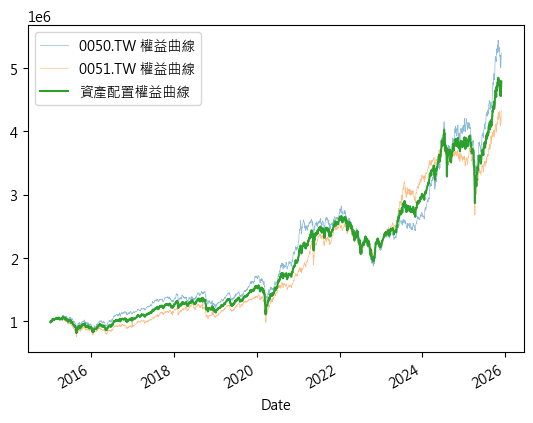

In [22]:
# 資產配置 權益曲線計算
cap_df = (returns).copy()
cap_df["mix"] = 0
margin = 1000000
for prod in portfolio.keys():
    # 計算單商品權益曲線
    cap_df[prod] = margin * ((returns[prod]+1).cumprod())
    cap_df[prod].plot(label=f"{prod} 權益曲線", legend=True, linewidth=0.5, alpha=0.5)   
    # 分配資產比例
    cap_df["mix"] += cap_df[prod] * portfolio[prod]
# 繪製資產配置的權益曲線圖
cap_df["mix"].plot(label="資產配置權益曲線", legend=True)